Only to ensure Onyxia GPUs to work.

In [1]:
# Onyxia GPU compatible torch version
import sys
!{sys.executable} -m pip install torch==2.11.0 torchaudio torchvision \
    --index-url https://download.pytorch.org/whl/cu126 \
    --force-reinstall

Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached torch-2.11.0%2Bcu126-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached torchaudio-2.11.0%2Bcu126-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
  Using cached torchvision-0.26.0%2Bcu126-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached cuda_bindings-12.9.4-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 100.7 MB/s  0:00

# Topic modeling

Here is our full implementation of a BERTopic unsupervised model applied to biathlon. 
*Please note that if you try to run the code, the topics described in this notebook might change of index.*

Creation of the corpus dataframe.
*If you want to analyse another sport, please change the path accordingly.*

In [78]:
import pandas as pd
import os

data_path = "PESSD/biath/"

df = pd.DataFrame()
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        temp = pd.read_csv(os.path.join(data_path, file))
        df = pd.concat([df, temp])


Small preporcessing : removing non relevant texts, nouns, stopwords and splitting interventions into sentences.

In [79]:
import re
import string

# Removing music and noise (only technical commentary)
df = df[(df["main_g"]=="female")|(df["main_g"]=="male")]

# text to sentences
df["text"] = df["text"].apply(lambda x : x.split(". "))
df = df.explode("text")

# Removes all words with capitals
df["text"] = df["text"].apply(lambda x : re.sub(r"\s*[A-Z]\w*\s*", " ", x).strip())

# Removes empty texts
df = df[df["text"].str.strip() != ""]

# Remove punctuation
df ["text"] = df["text"].apply(lambda x : x.translate(str.maketrans('', '', string.punctuation.replace("'", ""))))

Adding metadata of the files (gender of the athletes).

In [80]:
df["ID"] = df["audio_file"].str.replace("_wav.wav","")
df = df.merge(pd.read_csv("metadata.csv"), on="ID")
df

,start,stop,text,main_speaker,main_g,audio_file,ID,g_ath
0,0.00,12.20,on va prier en ce dimanche pour l'équipe de a...,SPEAKER_02,male,BAH_wav.wav,BAH,H
1,12.20,28.80,ça,SPEAKER_03,male,BAH_wav.wav,BAH,H
2,12.20,28.80,au moment où lance une attaque avec son coéq...,SPEAKER_03,male,BAH_wav.wav,BAH,H
3,28.80,31.80,surtout dans cette zone oui,SPEAKER_08,male,BAH_wav.wav,BAH,H
4,31.80,38.80,travail des techniciens on voit la glisse des,SPEAKER_02,male,BAH_wav.wav,BAH,H
...,...,...,...,...,...,...,...,...
8765,2661.76,2710.56,franchement l'équipe de il faut qu'on fasse t...,SPEAKER_02,male,BMF_wav.wav,BMF,F
8766,2661.76,2710.56,je ne sais pas en attendant les réactions évi...,SPEAKER_02,male,BMF_wav.wav,BMF,F
8767,2661.76,2710.56,si est avec vous et veut réagir c'est open bar,SPEAKER_02,male,BMF_wav.wav,BMF,F
8768,2661.76,2710.56,que là je crois que nous on n'a plus de mots,SPEAKER_02,male,BMF_wav.wav,BMF,F


Unserpervised topic model based on the corpus.
*If using CPU, please remove the "device" argument in* `SentenceTransformer`.

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
import hdbscan

# Stopwords list
STOPWORDS = [x.strip() for x in open('stopwords.txt').readlines()]

# Docs 
docs = df["text"]

# Vectorizer for topic representation
vectorizer_model = CountVectorizer(
    stop_words=STOPWORDS,
    ngram_range=(1,2),
    min_df=2
    #token_pattern=r"\b(?!\w*[A-Z])\w+\b" # theoreticaly removes words with capital letters once embeddings are done
)

# To control for number and size of clusters
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=50,      # high for larger topics
    min_samples=10,
    cluster_selection_epsilon=0.1,
    cluster_selection_method='leaf',
    prediction_data=True
)

# Load CamemBERT embedding model
embedding_model = SentenceTransformer("dangvantuan/sentence-camembert-base", device="cuda") # remove device if CPU

# Build BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    hdbscan_model=hdbscan_model,
    language="french",
    calculate_probabilities=True,
    verbose=True,
    seed_topic_list=None    
)

# Fit the model
topics, probs = topic_model.fit_transform(docs)

# Show discovered topics
# print(topic_model.get_topic_info())

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4396.31it/s]
CamembertModel LOAD REPORT from: dangvantuan/sentence-camembert-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-29 19:46:03,772 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 275/275 [00:14<00:00, 19.11it/s]
2026-04-29 19:46:18,228 - BERTopic - Embedding - Completed ✓
2026-04-29 19:46:18,229 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-29 19:47:38,956 - BERTopic - Dimensionality - Comp

In [69]:
# Visualize topic hierarchy
topic_model.visualize_hierarchy()

One can see that around 39% of the corpus is not attributed to a topic (3088/8770). The attributed texts are rather uniformously distributed across topics.
The names of the topic also indicates one potential empty topic (8).

In [70]:
topic_model.get_topic_info()[["Topic", "Name","Count"]].head()

,Topic,Name,Count
0,-1,-1_secondes_individuel_10_sprint,3088
1,0,0_tir_tir tir_tireur_tirs,307
2,1,1_skis_ski_temps ski_rapide,258
3,2,2_position_tête_place_3e,247
4,3,3_attention_aïe_oui_également,231


Adding topics and topic probabilites to the corpus dataframe.

In [81]:
df["topic"] = topics
df["topic_prob"] = probs.max(axis=1)

One can now check the content of each topic by file (ie discipline or moment of the competition).

In [72]:
# Sentences of topic i and by sport
for _, j in df[df["topic"]==4][["text","ID"]].head(15).iterrows():
    print(j["ID"],"_", j["text"])

BAH _  c'est beau ce qu'il fait
BAH _ est bien
BAH _ est bien là
BAH _ est vraiment bien
BAH _ justement des fois ça
BAH _ nous fait mentir le
BAH _  votre pote du  nous a dit tout à l'heure
BAH _ a envie de connaître votre avis parce que c'est vrai
BAH _ sont capables de plein de choses et  c'est cette surprise
BAH _ est un atout incroyable
BAH _ c'est vrai que
BAH _ a vu
BAH _ qu'on voit regardez intéressant 
BAH _ très bien
BAH _ là je trouve que  j'espère justement c'est lui qui se connaît


One can also check the main words shaping a topic.

In [67]:
topic_model.get_topic(4)

[('surprise', np.float64(0.10421614719503342)),
 ('image', np.float64(0.07580232499992169)),
 ('énorme', np.float64(0.07295126228796625)),
 ('incroyable', np.float64(0.07010848728958936)),
 ('magnifique', np.float64(0.06452572593226864)),
 ('intéressant', np.float64(0.054541985487438806)),
 ('voir', np.float64(0.053927241151425456)),
 ('nouvelle', np.float64(0.048634174858644165)),
 ('qualités', np.float64(0.046015808021464655)),
 ('exceptionnel', np.float64(0.0459864073319089))]

Topic 8 is indeed empty and can be removed from the corpus.

In [82]:
# Sentences of topic i and by sport
for _, j in df[df["topic"]==8][["text","ID"]].head().iterrows():
    print(j["ID"],"_", j["text"])

df = df[df["topic"]!=8]

BAH _ 
BAH _ 
BAH _ 
BAH _ 
BAH _ 


To summerise the information, the share of commentary on women(*F*), men (*H*) and both (*M*) are computed by topic.

In [83]:
# Only classified docs
clf = df[df["topic"]!=-1]
adf = pd.DataFrame()
for i in clf["topic"].unique() :
    tmp = df[df["topic"]==i]
    tmp = tmp["g_ath"].value_counts(normalize=True)
    tmp = pd.DataFrame([{
    "topic": f"topic_{i}",
    "M": tmp.get("M", 0),
    "F": tmp.get("F", 0),
    "H": tmp.get("H", 0)
}])
    adf = pd.concat([adf,tmp])

# All topics
tmp = clf["g_ath"].value_counts(normalize=True)
tmp = pd.DataFrame([{
    "topic": "all_topics",
    "M": tmp.get("M", 0),
    "F": tmp.get("F", 0),
    "H": tmp.get("H", 0)
}])
adf = pd.concat([adf,tmp])

for col in ["M", "F", "H"]:
    ref = tmp[col]
    adf[f"{col}_diff"] = adf[col] - ref
    adf[f"{col}_diff"] = adf[f"{col}_diff"].apply(
        lambda x: f"{x*100:+.1f}%" if pd.notna(x) else ""
    )

adf.sort_values(
    by='topic',
    key=lambda s: s.str.extract(r'(\d+)')[0].astype(float).fillna(-1)
).head()


,topic,M,F,H,M_diff,F_diff,H_diff
0,all_topics,0.105407,0.370836,0.523758,+0.0%,+0.0%,+0.0%
0,topic_0,0.061889,0.400651,0.537459,-4.4%,+3.0%,+1.4%
0,topic_1,0.116279,0.368217,0.515504,+1.1%,-0.3%,-0.8%
0,topic_2,0.101215,0.396761,0.502024,-0.4%,+2.6%,-2.2%
0,topic_3,0.103896,0.372294,0.523810,-0.2%,+0.1%,+0.0%


One can follow the same logic but with the gender of the commentator.

In [84]:
# Only classified docs
df["main_g"] = df["main_g"].map({"male" : "H", "female" : "F"})
clf = df[df["topic"]!=-1]
cdf = pd.DataFrame()
for i in clf["topic"].unique() :
    tmp = df[df["topic"]==i]
    tmp = tmp["main_g"].value_counts(normalize=True)
    tmp = pd.DataFrame([{
    "topic": f"topic_{i}",
    "F": tmp.get("F", 0),
    "H": tmp.get("H", 0)
}])
    cdf = pd.concat([cdf,tmp])

# All topics
tmp = clf["main_g"].value_counts(normalize=True)
tmp = pd.DataFrame([{
    "topic": "all_topics",
    "F": tmp.get("F", 0),
    "H": tmp.get("H", 0)
}])
cdf = pd.concat([cdf,tmp])

for col in ["F", "H"]:
    ref = tmp[col]
    cdf[f"{col}_diff"] = cdf[col] - ref
    cdf[f"{col}_diff"] = cdf[f"{col}_diff"].apply(
        lambda x: f"{x*100:+.1f}%" if pd.notna(x) else ""
    )

cdf.sort_values(
    by='topic',
    key=lambda s: s.str.extract(r'(\d+)')[0].astype(float).fillna(-1)
).head()


,topic,F,H,F_diff,H_diff
0,all_topics,0.201529,0.798471,+0.0%,+0.0%
0,topic_0,0.338762,0.661238,+13.7%,-13.7%
0,topic_1,0.306202,0.693798,+10.5%,-10.5%
0,topic_2,0.117409,0.882591,-8.4%,+8.4%
0,topic_3,0.160173,0.839827,-4.1%,+4.1%


Plotting gender share difference for commentary and athletes.

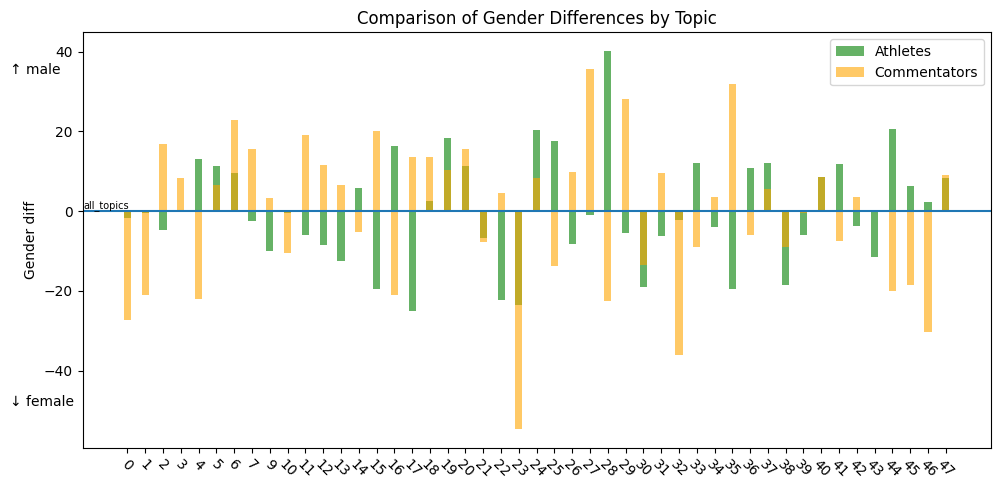

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def prepare_df(df):
    df = df.copy()
    for col in ['F_diff', 'H_diff']:
        df[col] = df[col].str.replace('%', '').astype(float)
    # single metric: male vs female dominance
    df['gender_diff'] = df['H_diff'] - df['F_diff']
    return df

adf_p = prepare_df(adf)
cdf_p = prepare_df(cdf)

adf_p = adf_p.sort_values(
    by='topic',
    key=lambda s: s.str.extract(r'(\d+)')[0].astype(float).fillna(-1)
)

cdf_p = cdf_p.sort_values(
    by='topic',
    key=lambda s: s.str.extract(r'(\d+)')[0].astype(float).fillna(-1)
)

adf_p = adf_p[adf_p['topic'] != 'all_topics']


cdf_p = cdf_p[cdf_p['topic'] != 'all_topics']

x = np.arange(len(adf_p['topic']))

plt.figure(figsize=(10,5))

# Plot both with slight offset + transparency
plt.bar(x, adf_p['gender_diff'], width=0.4, alpha=0.6, label='Athletes', color='green')
plt.bar(x, cdf_p['gender_diff'], width=0.4, alpha=0.6, label='Commentators', color='orange')
plt.text(0.1, 0.7, "all_topics", rotation=0, ha='right', fontsize=7)

plt.axhline(0)
plt.xticks(x, adf_p['topic'].str.replace("topic_",""), rotation=-45)
plt.ylabel("Gender diff")
plt.title("Comparison of Gender Differences by Topic")
plt.annotate("↑ male", xy=(-0.08, 0.9), xycoords='axes fraction', fontsize=10)
plt.annotate("↓ female", xy=(-0.08, 0.1), xycoords='axes fraction', fontsize=10)
plt.legend()

plt.tight_layout()
plt.show()

To see if the topics are consistent, we run the model without 20% of the corpus.
*GPU here is mandatory.*

In [30]:
# Main words of current model themes

reference = set()
for topic_id in topic_model.get_topics():
    if topic_id == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(topic_id)[:10]]
    reference.add(tuple(sorted(words)))

10 runs at 80%. Stability is measured with the Jaccard Index between reference model topics and 80% runs topics. If the index is higher than 0.2 7 times or more, the topic is considered stable.

In [32]:
from sklearn.utils import resample
from collections import Counter

# List of words for each topic for each model
all_topics_words = []

# Number of runs
nb_iter = 10

for i in range(nb_iter):

    # First, resample 80% of docs
    sample = resample(docs, n_samples=int(len(docs) * 0.8), random_state=i)

    # Same model specification
    model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    hdbscan_model=hdbscan_model,
    language="french",
    calculate_probabilities=True,
    verbose=True,
    seed_topic_list=None    
)
    model.fit(sample)
    
    # Top 10 words per topic
    top_words = set()
    for topic_id in model.get_topics():
        if topic_id == -1:
            continue
        words = [w for w, _ in model.get_topic(topic_id)[:10]]
        top_words.add(tuple(sorted(words)))
    
    all_topics_words.append(top_words)


# Jaccard similarity index
def jaccard(t1, t2):
    s1, s2 = set(t1), set(t2)
    return len(s1 & s2) / len(s1 | s2)

# Topic stability
"""
Measures similarity between reference topic and topics found in other runs.

Thresholds for stability are determined by Jaccard index (threshold) and number of occurences (min_run)
"""
def is_stable(topic, all_runs, threshold=0.2, min_runs=7):
    count = 0
    for run_topics in all_runs:
        if any(jaccard(topic, t) >= threshold for t in run_topics):
            count += 1
    return count >= min_runs


stable_topics = [t for t in reference if is_stable(t, all_topics_words)]

print(f"Stable topics (≥7 runs out of 10) : {len(stable_topics)}")
for t in stable_topics:
    print(t)


2026-04-29 19:58:41,754 - BERTopic - Embedding - Transforming documents to embeddings.
Batches:   0%|          | 0/220 [00:00<?, ?it/s]

Batches: 100%|██████████| 220/220 [00:11<00:00, 18.45it/s]
2026-04-29 19:58:53,734 - BERTopic - Embedding - Completed ✓
2026-04-29 19:58:53,735 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-29 19:59:37,346 - BERTopic - Dimensionality - Completed ✓
2026-04-29 19:59:37,354 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-29 19:59:38,336 - BERTopic - Cluster - Completed ✓
2026-04-29 19:59:38,342 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-29 19:59:38,457 - BERTopic - Representation - Completed ✓
2026-04-29 19:59:38,633 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 220/220 [00:11<00:00, 19.70it/s]
2026-04-29 19:59:49,840 - BERTopic - Embedding - Completed ✓
2026-04-29 19:59:49,841 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-29 20:00:33,357 - BERTopic - Dimensionality - Completed ✓
2026-04-29 20:00:33,359 -

Stable topics (≥7 runs out of 10) : 22
('couché', 'engagé', 'installer', 'secondes tir', 'tir', 'tir couché', 'tir tir', 'tireur', 'tirs', 'tiré')
('75', '75 réussite', '90', 'coucher', 'couché', 'réussite', 'réussite coucher', 'saison', 'tapis', 'tourne')
('', '', '', '', '', '', '', '', '', '')
('neige', 'rapide', 'rapide skis', 'ski', 'skier', 'skis', 'temps', 'temps ski', 'vite', 'vite skis')
('mixte', 'passage', 'relais', 'relais instant', 'relais mixte', 'relais relais', 'relayeur', 'relayeurs', 'zone', 'zone mixte')
('champion', 'champion olympique', 'championne', 'championne olympique', 'olympique', 'olympique titre', 'olympiques', 'titre', 'titre olympique', 'vicechampion olympique')
('perd', 'perd temps', 'perdre', 'perdu', 'perdu temps', 'temps', 'temps perd', 'temps perdu', 'temps temps', 'train perdre')
('champion monde', 'championne', 'championne monde', 'gagné', 'gros globe', 'monde', 'remporté', 'remporté titre', 'titre', 'titre mondial')
('anneau', 'anneau pénalité', '